# SPARC Example 12: LITTLE THINGS Dwarf Irregulars

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

LITTLE THINGS (Local Irregulars That Trace Luminosity Extremes)
provides 26 dwarf irregular galaxies with high-resolution VLA data.
These are the smallest, darkest-matter-dominated galaxies in the corpus.

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

rows = []
with open('rotation_curve_corpus_v7_flat.csv') as f:
    for r in csv.DictReader(f):
        if r['survey'] == 'LITTLE_THINGS':
            rows.append(r)

print(f"LITTLE THINGS galaxies: {len(rows)}")
dists = [float(r['distance_mpc']) for r in rows]
vmaxs = [float(r['vrot_max_kms']) for r in rows if r['vrot_max_kms']]
print(f"Distance range: {min(dists):.1f} -- {max(dists):.1f} Mpc")
print(f"Vrot_max range: {min(vmaxs):.1f} -- {max(vmaxs):.1f} km/s")
print(f"Median Vrot_max: {np.median(vmaxs):.1f} km/s")
print(f"\nAll LITTLE THINGS galaxies:")
for r in sorted(rows, key=lambda x: float(x['vrot_max_kms'] or 0), reverse=True):
    print(f"  {r['galaxy']:<15} D={float(r['distance_mpc']):.1f} Mpc  "
          f"Vmax={r['vrot_max_kms']} km/s")

LITTLE THINGS galaxies: 26
Distance range: 0.7 -- 10.3 Mpc
Vrot_max range: 12.0 -- 132.7 km/s
Median Vrot_max: 45.0 km/s

All LITTLE THINGS galaxies:
  NGC_3738        D=4.9 Mpc  Vmax=132.74 km/s
  DDO_46          D=6.1 Mpc  Vmax=77.4963 km/s
  DDO_47          D=5.2 Mpc  Vmax=68.9045 km/s
  DDO_168         D=4.3 Mpc  Vmax=67.4141 km/s
  DDO_101         D=6.4 Mpc  Vmax=64.92 km/s
  DDO_52          D=10.3 Mpc  Vmax=61.72 km/s
  NGC_2366        D=3.4 Mpc  Vmax=60.8706 km/s
  HARO_36         D=9.3 Mpc  Vmax=58.22 km/s
  DDO_87          D=7.7 Mpc  Vmax=56.63 km/s
  DDO_154         D=3.7 Mpc  Vmax=51.13 km/s
  NGC_1569        D=3.4 Mpc  Vmax=49.01 km/s
  DDO_133         D=3.5 Mpc  Vmax=47.5549 km/s
  UGC_8508        D=2.6 Mpc  Vmax=46.08 km/s
  DDO_70          D=1.3 Mpc  Vmax=43.94 km/s
  HARO_29         D=5.9 Mpc  Vmax=43.49 km/s
  DDO_126         D=4.9 Mpc  Vmax=39.516 km/s
  F564-V3         D=8.7 Mpc  Vmax=39.22 km/s
  DDO_50          D=3.4 Mpc  Vmax=38.84 km/s
  WLM             D=1.0 Mpc

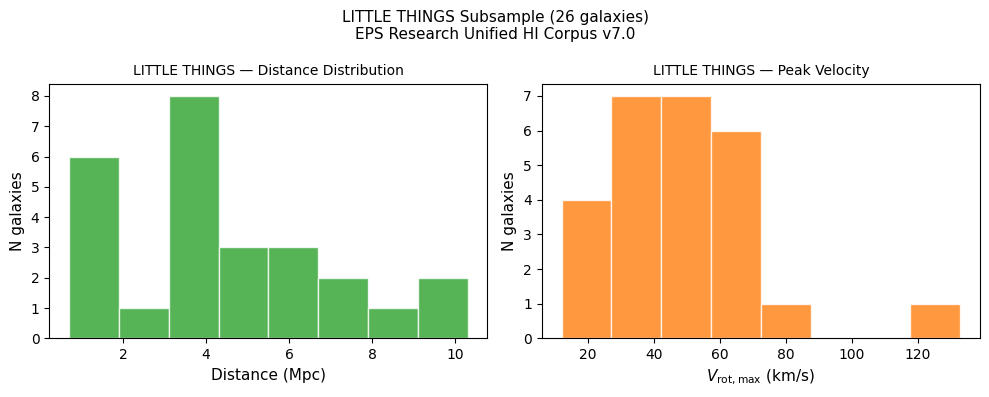

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(dists, bins=8, color='#2ca02c', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Distance (Mpc)', fontsize=11)
axes[0].set_ylabel('N galaxies', fontsize=11)
axes[0].set_title('LITTLE THINGS — Distance Distribution', fontsize=10)

axes[1].hist(vmaxs, bins=8, color='#ff7f0e', alpha=0.8, edgecolor='white')
axes[1].set_xlabel(r'$V_{\rm rot,max}$ (km/s)', fontsize=11)
axes[1].set_ylabel('N galaxies', fontsize=11)
axes[1].set_title('LITTLE THINGS — Peak Velocity', fontsize=10)

plt.suptitle('LITTLE THINGS Subsample (26 galaxies)\n'
             'EPS Research Unified HI Corpus v7.0', fontsize=11)
plt.tight_layout()
plt.savefig('ex12_little_things.png', dpi=150, bbox_inches='tight')
plt.show()